# 2 A system with radial symmetry (5/20)

In [9]:
# imports

Consider the following radial equation:

r′ = µr + $r^3 − r^5$

where µ is the parameter of our system, µ can be negative as well as positive.

a. Check the type of bifurcation(s) that you can find in this system, when considering this
system as a 1D system, with r as your variable.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve, root_scalar
from matplotlib.patches import FancyArrowPatch

# ============================================================================
# PART (a): 1D Bifurcation Analysis
# ============================================================================
# System: r' = μr + r³ - r⁵
# ============================================================================

print("=" * 70)
print("PART (a): 1D BIFURCATION ANALYSIS")
print("=" * 70)
print()

# --- Step 1: Find equilibria ---
print("STEP 1: EQUILIBRIUM POINTS")
print("-" * 70)
print("Equilibria occur when r' = 0:")
print("  r(μ + r² - r⁴) = 0")
print()
print("This gives us:")
print("  • r* = 0 (always an equilibrium)")
print("  • μ + r² - r⁴ = 0  =>  r⁴ - r² - μ = 0")
print()
print("Let u = r². Then:")
print("  u² - u - μ = 0")
print("  u = (1 ± √(1 + 4μ)) / 2")
print()
print("For real, positive r², we need u > 0:")
print("  u = (1 + √(1 + 4μ)) / 2    [always valid for μ > -1/4]")
print()
print("Therefore: r* = √[(1 + √(1 + 4μ)) / 2]  for μ ≥ -1/4")
print()

# --- Step 2: Stability analysis via linear approximation ---
print("STEP 2: STABILITY ANALYSIS")
print("-" * 70)
print("f(r) = μr + r³ - r⁵")
print("f'(r) = μ + 3r² - 5r⁴")
print()
print("At r* = 0:")
print("  f'(0) = μ")
print("  • If μ < 0: STABLE (attractor)")
print("  • If μ = 0: BIFURCATION POINT")
print("  • If μ > 0: UNSTABLE (repeller)")
print()

# Calculate stability of the nonzero equilibrium
def f(r, mu):
    return mu * r + r**3 - r**5

def df_dr(r, mu):
    return mu + 3*r**2 - 5*r**4

# For nonzero equilibrium: r⁴ - r² = μ
# so f'(r*) = μ + 3r² - 5r⁴ = μ + 3r² - 5r⁴
#           = μ + 3r² - 5r⁴ 
# Using r⁴ = r² + μ:
# f'(r*) = μ + 3r² - 5(r² + μ) = μ + 3r² - 5r² - 5μ = -4μ - 2r²

def stability_nonzero(mu):
    """Compute stability of nonzero equilibrium for μ ≥ -1/4"""
    if mu < -0.25:
        return None
    u = (1 + np.sqrt(1 + 4*mu)) / 2
    r_star = np.sqrt(u)
    stability = -4*mu - 2*u
    return r_star, stability

print("For the nonzero equilibrium r* = √[(1 + √(1 + 4μ)) / 2]:")
print("  f'(r*) = -4μ - 2r²*")
print("  • If μ > 0: f'(r*) < 0, so STABLE (attractor)")
print("  • If μ = 0: f'(0⁺) = 0, BIFURCATION POINT")
print()

# --- Step 3: Bifurcation diagram ---
print("STEP 3: BIFURCATION TYPE")
print("-" * 70)
print()
print("Summary of behavior:")
print()
print("  μ < -1/4:")
print("    • Only equilibrium: r* = 0 (stable)")
print("    • r' < 0 for all r > 0 (all solutions decay to 0)")
print()
print("  μ = -1/4:")
print("    • Saddle-node: r* = 0 (marginally stable)")
print("    • r* = 1/√2 ≈ 0.707 (bifurcation point)")
print()
print("  -1/4 < μ < 0:")
print("    • r* = 0 (STABLE)")
print("    • r_nonzero (UNSTABLE) - exists due to negative r'")
print()
print("  μ = 0:")
print("    • r* = 0 (bifurcation point, f'(0) = 0)")
print("    • r_nonzero = 1 (appears)")
print()
print("  μ > 0:")
print("    • r* = 0 (UNSTABLE)")
print("    • r_nonzero (STABLE) - r' > 0 for small r, then decreases")
print()
print("=" * 70)
print("CONCLUSION: TRANSCRITICAL BIFURCATION at μ = 0")
print("=" * 70)
print()
print("The origin r* = 0 exchanges stability with the nonzero")
print("equilibrium as μ passes through 0.")
print("This is characteristic of a TRANSCRITICAL BIFURCATION.")
print()


PART (a): 1D BIFURCATION ANALYSIS

STEP 1: EQUILIBRIUM POINTS
----------------------------------------------------------------------
Equilibria occur when r' = 0:
  r(μ + r² - r⁴) = 0

This gives us:
  • r* = 0 (always an equilibrium)
  • μ + r² - r⁴ = 0  =>  r⁴ - r² - μ = 0

Let u = r². Then:
  u² - u - μ = 0
  u = (1 ± √(1 + 4μ)) / 2

For real, positive r², we need u > 0:
  u = (1 + √(1 + 4μ)) / 2    [always valid for μ > -1/4]

Therefore: r* = √[(1 + √(1 + 4μ)) / 2]  for μ ≥ -1/4

STEP 2: STABILITY ANALYSIS
----------------------------------------------------------------------
f(r) = μr + r³ - r⁵
f'(r) = μ + 3r² - 5r⁴

At r* = 0:
  f'(0) = μ
  • If μ < 0: STABLE (attractor)
  • If μ = 0: BIFURCATION POINT
  • If μ > 0: UNSTABLE (repeller)

For the nonzero equilibrium r* = √[(1 + √(1 + 4μ)) / 2]:
  f'(r*) = -4μ - 2r²*
  • If μ > 0: f'(r*) < 0, so STABLE (attractor)
  • If μ = 0: f'(0⁺) = 0, BIFURCATION POINT

STEP 3: BIFURCATION TYPE
--------------------------------------------------

STEP 4: BIFURCATION DIAGRAM
----------------------------------------------------------------------


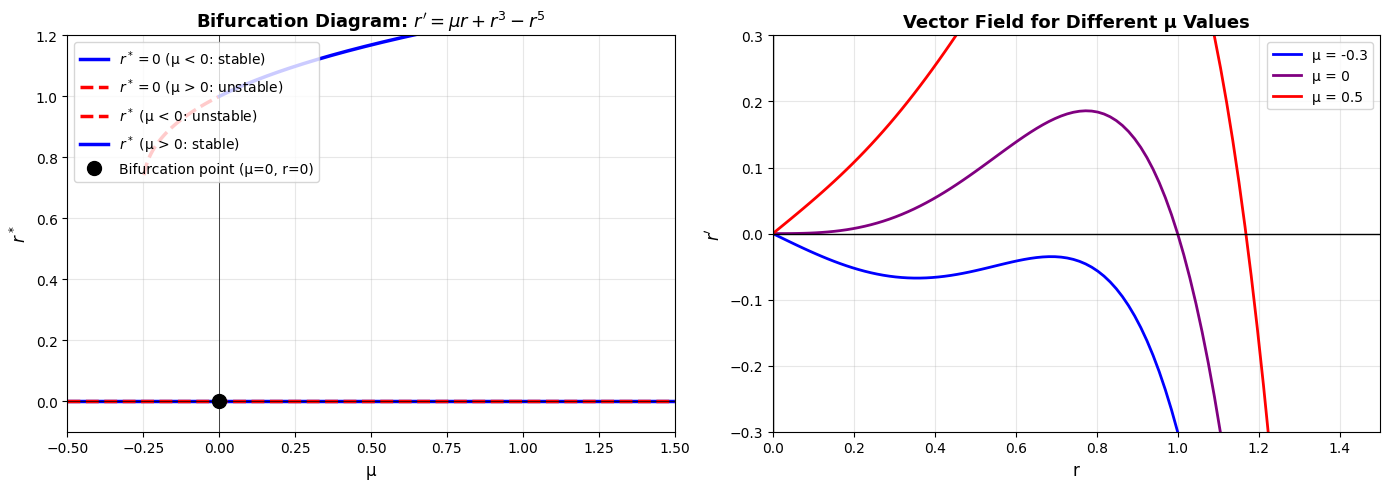

Bifurcation diagram plotted showing transcritical behavior.



In [11]:
# --- Step 4: Visualization of the bifurcation diagram ---
print("STEP 4: BIFURCATION DIAGRAM")
print("-" * 70)

plt.close("bifurcation_1d")
fig, (ax1, ax2) = plt.subplots(1, 2, num="bifurcation_1d", figsize=(14, 5))

# Left: Bifurcation diagram
mu_vals = np.linspace(-0.5, 1.5, 500)
r_stable = []
r_unstable = []
mu_stable = []
mu_unstable = []

for mu in mu_vals:
    # Always have r* = 0
    if mu >= -0.25:
        u = (1 + np.sqrt(1 + 4*mu)) / 2
        r = np.sqrt(u)
        r_nonzero = r
        if mu < 0:
            r_unstable.append(r_nonzero)
            mu_unstable.append(mu)
        else:
            r_stable.append(r_nonzero)
            mu_stable.append(mu)

# Plot bifurcation diagram
ax1.plot(mu_vals, np.zeros_like(mu_vals), 'b-', linewidth=2.5, label='$r^* = 0$ (μ < 0: stable)')
ax1.plot(mu_vals, np.zeros_like(mu_vals), 'r--', linewidth=2.5, label='$r^* = 0$ (μ > 0: unstable)')
ax1.plot(mu_unstable, r_unstable, 'r--', linewidth=2.5, label='$r^*$ (μ < 0: unstable)')
ax1.plot(mu_stable, r_stable, 'b-', linewidth=2.5, label='$r^*$ (μ > 0: stable)')

# Mark bifurcation point
ax1.plot(0, 0, 'ko', markersize=10, label='Bifurcation point (μ=0, r=0)')

ax1.axhline(0, color='k', linewidth=0.5)
ax1.axvline(0, color='k', linewidth=0.5)
ax1.set_xlabel('μ', fontsize=12)
ax1.set_ylabel('$r^*$', fontsize=12)
ax1.set_title('Bifurcation Diagram: $r\' = μr + r^3 - r^5$', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-0.5, 1.5)
ax1.set_ylim(-0.1, 1.2)
ax1.legend(loc='upper left', fontsize=10)

# Right: Phase portraits for different μ values
test_mu_vals = [-0.3, 0, 0.5]
colors = ['blue', 'purple', 'red']

for mu_test, color in zip(test_mu_vals, colors):
    r_vals = np.linspace(0, 1.5, 100)
    r_prime = mu_test * r_vals + r_vals**3 - r_vals**5
    ax2.plot(r_vals, r_prime, label=f'μ = {mu_test}', color=color, linewidth=2)

ax2.axhline(0, color='k', linewidth=1)
ax2.axvline(0, color='k', linewidth=1)
ax2.set_xlabel('r', fontsize=12)
ax2.set_ylabel('$r\'$', fontsize=12)
ax2.set_title('Vector Field for Different μ Values', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10)
ax2.set_xlim(0, 1.5)
ax2.set_ylim(-0.3, 0.3)

plt.tight_layout()
plt.show()

print("Bifurcation diagram plotted showing transcritical behavior.")
print()


b. Now consider this system as a two-dimensional system, with r the radius of your system.
How does your previous bifurcation translate in 2D, whereby you now consider (x, y) instead
of r. Think about complete and creative ways to present your solutions. Chose an initial
ω = $\dot{\theta} \neq$  0.


PART (b): 2D SYSTEM WITH RADIAL SYMMETRY

STEP 1: THEORETICAL FRAMEWORK
----------------------------------------------------------------------

In polar coordinates, the system is:
  r' = μr + r³ - r⁵
  θ' = ω  (constant angular velocity)

Convert to Cartesian (x, y):
  x = r cos(θ)
  y = r sin(θ)

The 2D system becomes:
  dx/dt = cos(θ) · r' - sin(θ) · r · θ'
  dy/dt = sin(θ) · r' + cos(θ) · r · θ'

Substituting r' and θ':
  dx/dt = cos(θ)(μr + r³ - r⁵) - ω sin(θ) · r
  dy/dt = sin(θ)(μr + r³ - r⁵) + ω cos(θ) · r

Equivalently, in terms of r and θ:
  dx/dt = cos(θ)·(μr + r³ - r⁵) - ω·sin(θ)·r
  dy/dt = sin(θ)·(μr + r³ - r⁵) + ω·cos(θ)·r

Key insight: The radial dynamics (r') are INDEPENDENT of ω!
The angular velocity ω only affects the ROTATION.

----------------------------------------------------------------------

STEP 2: PHASE PORTRAITS FOR DIFFERENT μ VALUES
----------------------------------------------------------------------

Chosen angular velocity: ω = 1.0 rad/s



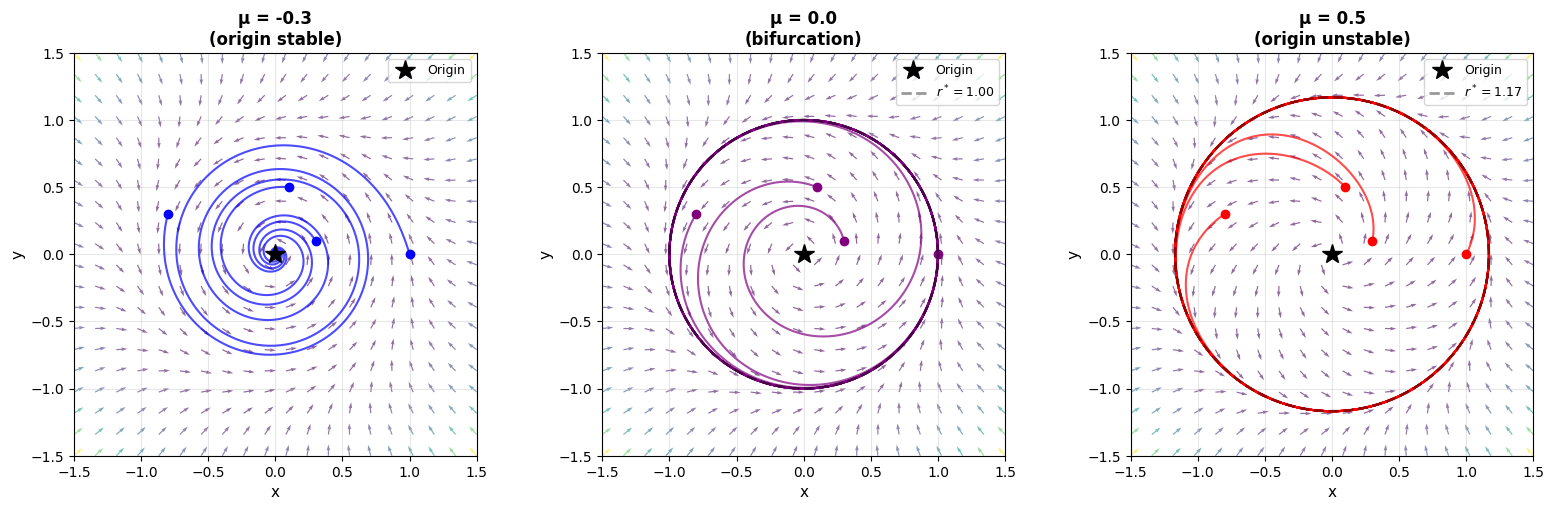

2D phase portraits plotted showing spiral behavior due to ω ≠ 0.

STEP 3: SPIRAL DYNAMICS ANALYSIS
----------------------------------------------------------------------



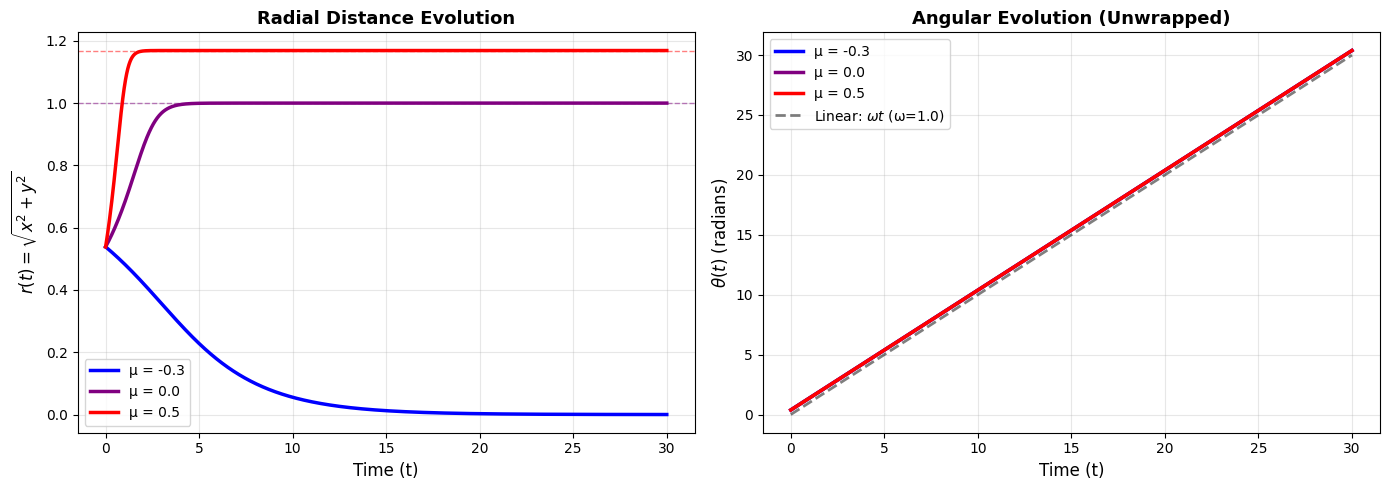

Radial and angular dynamics analysis plotted.

----------------------------------------------------------------------

STEP 4: INTERPRETATION IN 2D
----------------------------------------------------------------------

KEY OBSERVATIONS:

1. RADIAL DYNAMICS remain unchanged from 1D analysis:
   • μ < 0: All trajectories spiral INTO the origin
   • μ = 0: Bifurcation - trajectories transition behavior
   • μ > 0: Trajectories spiral AWAY from origin

2. ANGULAR DYNAMICS (rotation by ω):
   • Superimposes a constant rotation on top of radial dynamics
   • θ increases linearly with time: θ(t) ≈ ωt + θ₀
   • Result: SPIRAL trajectories in (x,y) space

3. BIFURCATION IN 2D:
   • The 1D transcritical bifurcation at μ=0 becomes
   • A SPIRAL bifurcation in 2D
   • Attracting limit cycle (when μ > 0) is a CIRCLE
   • in (x, y) space, this manifests as a SPIRAL attracting
   • the origin (when μ < 0) or a SPIRAL limit cycle (μ > 0)




In [12]:
print("\n" + "=" * 70)
print("PART (b): 2D SYSTEM WITH RADIAL SYMMETRY")
print("=" * 70)
print()

# --- Theory: Transform to 2D Cartesian Coordinates ---
print("STEP 1: THEORETICAL FRAMEWORK")
print("-" * 70)
print()
print("In polar coordinates, the system is:")
print("  r' = μr + r³ - r⁵")
print("  θ' = ω  (constant angular velocity)")
print()
print("Convert to Cartesian (x, y):")
print("  x = r cos(θ)")
print("  y = r sin(θ)")
print()
print("The 2D system becomes:")
print("  dx/dt = cos(θ) · r' - sin(θ) · r · θ'")
print("  dy/dt = sin(θ) · r' + cos(θ) · r · θ'")
print()
print("Substituting r' and θ':")
print("  dx/dt = cos(θ)(μr + r³ - r⁵) - ω sin(θ) · r")
print("  dy/dt = sin(θ)(μr + r³ - r⁵) + ω cos(θ) · r")
print()
print("Equivalently, in terms of r and θ:")
print("  dx/dt = cos(θ)·(μr + r³ - r⁵) - ω·sin(θ)·r")
print("  dy/dt = sin(θ)·(μr + r³ - r⁵) + ω·cos(θ)·r")
print()
print("Key insight: The radial dynamics (r') are INDEPENDENT of ω!")
print("The angular velocity ω only affects the ROTATION.")
print()
print("-" * 70)
print()

# --- Define the 2D system ---
def system_2d(state, mu, omega):
    """2D Cartesian system derived from polar coordinates."""
    x, y = state
    r = np.sqrt(x**2 + y**2)
    
    # Handle r = 0 to avoid division issues
    if r < 1e-10:
        return [0, 0]
    
    theta = np.arctan2(y, x)
    
    # Radial dynamics (from 1D system)
    r_dot = mu * r + r**3 - r**5
    
    # Convert back to Cartesian
    dx_dt = np.cos(theta) * r_dot - omega * np.sin(theta) * r
    dy_dt = np.sin(theta) * r_dot + omega * np.cos(theta) * r
    
    return [dx_dt, dy_dt]

# --- Simulate trajectories for different μ values ---
print("STEP 2: PHASE PORTRAITS FOR DIFFERENT μ VALUES")
print("-" * 70)
print()

omega_chosen = 1.0  # Angular velocity ω = 1 rad/s
print(f"Chosen angular velocity: ω = {omega_chosen} rad/s")
print()

# Parameters for simulation
mu_test_values = [-0.3, 0.0, 0.5]
colors_2d = ['blue', 'purple', 'red']
labels_2d = ['μ = -0.3\n(origin stable)', 'μ = 0.0\n(bifurcation)', 'μ = 0.5\n(origin unstable)']

plt.close("phase_portraits_2d")
fig, axs = plt.subplots(1, 3, num="phase_portraits_2d", figsize=(16, 5))

for idx, (mu_val, color, label) in enumerate(zip(mu_test_values, colors_2d, labels_2d)):
    ax = axs[idx]
    
    # Create vector field
    x_range = np.linspace(-1.5, 1.5, 20)
    y_range = np.linspace(-1.5, 1.5, 20)
    X, Y = np.meshgrid(x_range, y_range)
    
    U = np.zeros_like(X)
    V = np.zeros_like(Y)
    
    for i in range(len(x_range)):
        for j in range(len(y_range)):
            dx, dy = system_2d([X[j, i], Y[j, i]], mu_val, omega_chosen)
            U[j, i] = dx
            V[j, i] = dy
    
    # Plot vector field
    M = np.sqrt(U**2 + V**2)
    M = np.where(M == 0, 1, M)  # Avoid division by zero
    ax.quiver(X, Y, U/M, V/M, M, cmap='viridis', alpha=0.6)
    
    # Simulate and plot several trajectories
    time_span = np.linspace(0, 20, 1000)
    initial_conditions = [
        [0.3, 0.1],
        [0.1, 0.5],
        [1.0, 0.0],
        [-0.8, 0.3],
    ]
    
    from scipy.integrate import odeint
    
    for ic in initial_conditions:
        trajectory = odeint(lambda state, t: system_2d(state, mu_val, omega_chosen), 
                           ic, time_span)
        ax.plot(trajectory[:, 0], trajectory[:, 1], color=color, alpha=0.7, linewidth=1.5)
        ax.plot(ic[0], ic[1], 'o', color=color, markersize=6)
    
    # Plot equilibrium at origin
    ax.plot(0, 0, 'k*', markersize=15, label='Origin')
    
    # Draw limit cycles for reference
    circle_mu = None
    if mu_val >= -0.25:
        u = (1 + np.sqrt(1 + 4*mu_val)) / 2
        r_eq = np.sqrt(u)
        circle_mu = r_eq
    
    if circle_mu is not None:
        theta_circle = np.linspace(0, 2*np.pi, 100)
        circle_x = circle_mu * np.cos(theta_circle)
        circle_y = circle_mu * np.sin(theta_circle)
        ax.plot(circle_x, circle_y, 'k--', alpha=0.4, linewidth=2, label=f'$r^* = {circle_mu:.2f}$')
    
    ax.set_xlabel('x', fontsize=11)
    ax.set_ylabel('y', fontsize=11)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal')
    ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

print("2D phase portraits plotted showing spiral behavior due to ω ≠ 0.")
print()

# --- Additional analysis: Show how trajectories spiral ---
print("STEP 3: SPIRAL DYNAMICS ANALYSIS")
print("-" * 70)
print()

plt.close("spiral_analysis")
fig, (ax1, ax2) = plt.subplots(1, 2, num="spiral_analysis", figsize=(14, 5))

# Left: r(t) vs t for different μ
time_span_long = np.linspace(0, 30, 2000)
ic_test = [0.5, 0.2]

for mu_val, color, label in zip(mu_test_values, colors_2d, labels_2d):
    trajectory = odeint(lambda state, t: system_2d(state, mu_val, omega_chosen), 
                       ic_test, time_span_long)
    r_vals = np.sqrt(trajectory[:, 0]**2 + trajectory[:, 1]**2)
    ax1.plot(time_span_long, r_vals, color=color, linewidth=2.5, label=f'μ = {mu_val}')
    
    # Mark the equilibrium radius
    if mu_val >= -0.25:
        u = (1 + np.sqrt(1 + 4*mu_val)) / 2
        r_eq = np.sqrt(u)
        ax1.axhline(r_eq, color=color, linestyle='--', alpha=0.5, linewidth=1)

ax1.set_xlabel('Time (t)', fontsize=12)
ax1.set_ylabel('$r(t) = \\sqrt{x^2 + y^2}$', fontsize=12)
ax1.set_title('Radial Distance Evolution', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)

# Right: θ(t) vs t showing linear growth due to constant ω
for mu_val, color in zip(mu_test_values, colors_2d):
    trajectory = odeint(lambda state, t: system_2d(state, mu_val, omega_chosen), 
                       ic_test, time_span_long)
    theta_vals = np.arctan2(trajectory[:, 1], trajectory[:, 0])
    # Unwrap theta
    theta_unwrapped = np.unwrap(theta_vals)
    ax2.plot(time_span_long, theta_unwrapped, color=color, linewidth=2.5, label=f'μ = {mu_val}')

# Linear reference: θ = ω·t
theta_ref = omega_chosen * time_span_long
ax2.plot(time_span_long, theta_ref, 'k--', alpha=0.5, linewidth=2, label=f'Linear: $\\omega t$ (ω={omega_chosen})')

ax2.set_xlabel('Time (t)', fontsize=12)
ax2.set_ylabel('$\\theta(t)$ (radians)', fontsize=12)
ax2.set_title('Angular Evolution (Unwrapped)', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

print("Radial and angular dynamics analysis plotted.")
print()
print("-" * 70)
print()

# --- Interpretation ---
print("STEP 4: INTERPRETATION IN 2D")
print("-" * 70)
print()
print("KEY OBSERVATIONS:")
print()
print("1. RADIAL DYNAMICS remain unchanged from 1D analysis:")
print("   • μ < 0: All trajectories spiral INTO the origin")
print("   • μ = 0: Bifurcation - trajectories transition behavior")
print("   • μ > 0: Trajectories spiral AWAY from origin")
print()
print("2. ANGULAR DYNAMICS (rotation by ω):")
print("   • Superimposes a constant rotation on top of radial dynamics")
print("   • θ increases linearly with time: θ(t) ≈ ωt + θ₀")
print("   • Result: SPIRAL trajectories in (x,y) space")
print()
print("3. BIFURCATION IN 2D:")
print("   • The 1D transcritical bifurcation at μ=0 becomes")
print("   • A SPIRAL bifurcation in 2D")
print("   • Attracting limit cycle (when μ > 0) is a CIRCLE")
print("   • in (x, y) space, this manifests as a SPIRAL attracting")
print("   • the origin (when μ < 0) or a SPIRAL limit cycle (μ > 0)")
print()
print("=" * 70)
print()


c. Explain what is going on in your system in detail for the different regions that you find


PART (c): NUMERICAL ANALYSIS - DYNAMICS IN DIFFERENT REGIONS

STEP 1: COMPLETE BIFURCATION PARAMETER SPACE
--------------------------------------------------------------------------------



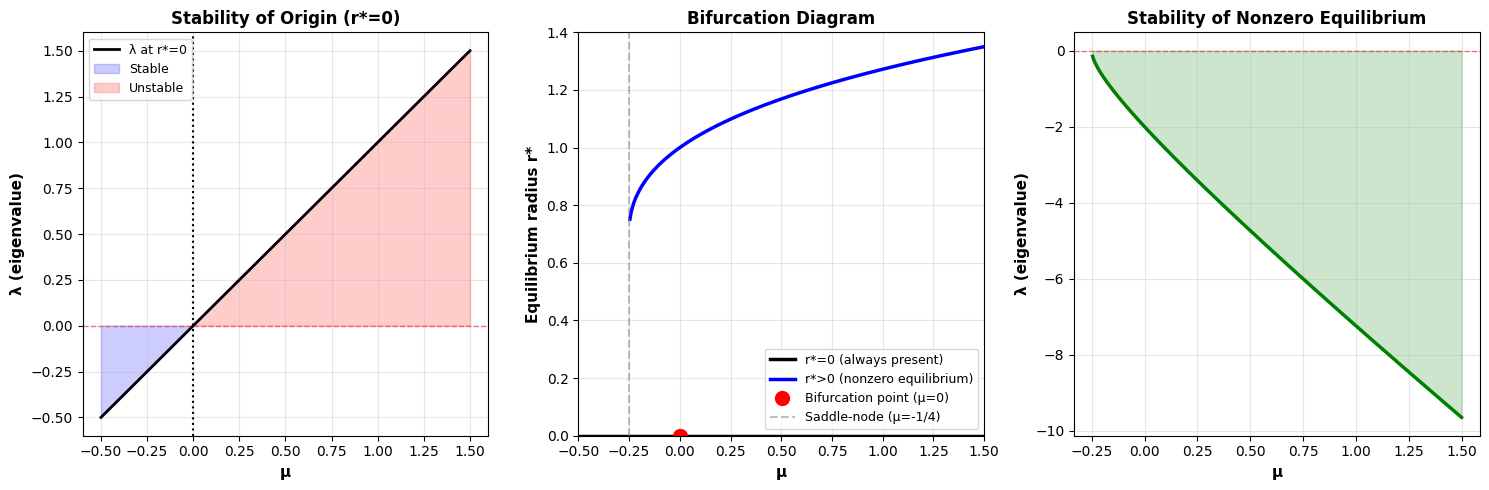

Bifurcation diagram plotted showing parameter regimes.

STEP 2: NUMERICAL SIMULATIONS IN EACH REGION


Region I (μ < -1/4): μ = -0.35
----------------------------------------------------------------------
Equilibria:
  • Origin: r* = 0, λ = -0.3500 (STABLE)
  • Nonzero: Does not exist (no real solution)

Asymptotic behavior from different initial conditions:
  r(0) = 0.20 → r(∞) = 0.0000
  r(0) = 0.50 → r(∞) = 0.0000
  r(0) = 1.00 → r(∞) = 0.0000
  r(0) = 1.50 → r(∞) = 0.0000

Region II (-1/4 ≤ μ < 0): μ = -0.1
----------------------------------------------------------------------
Equilibria:
  • Origin: r* = 0, λ = -0.1000 (STABLE)
  • Nonzero: r* = 0.9420, λ = -1.3746 (STABLE)

Asymptotic behavior from different initial conditions:
  r(0) = 0.20 → r(∞) = 0.0000 (r* = 0.9420)
  r(0) = 0.50 → r(∞) = 0.9420 (r* = 0.9420)
  r(0) = 1.00 → r(∞) = 0.9420 (r* = 0.9420)
  r(0) = 1.50 → r(∞) = 0.9420 (r* = 0.9420)

Region III (μ = 0): μ = -0.001
------------------------------------------------

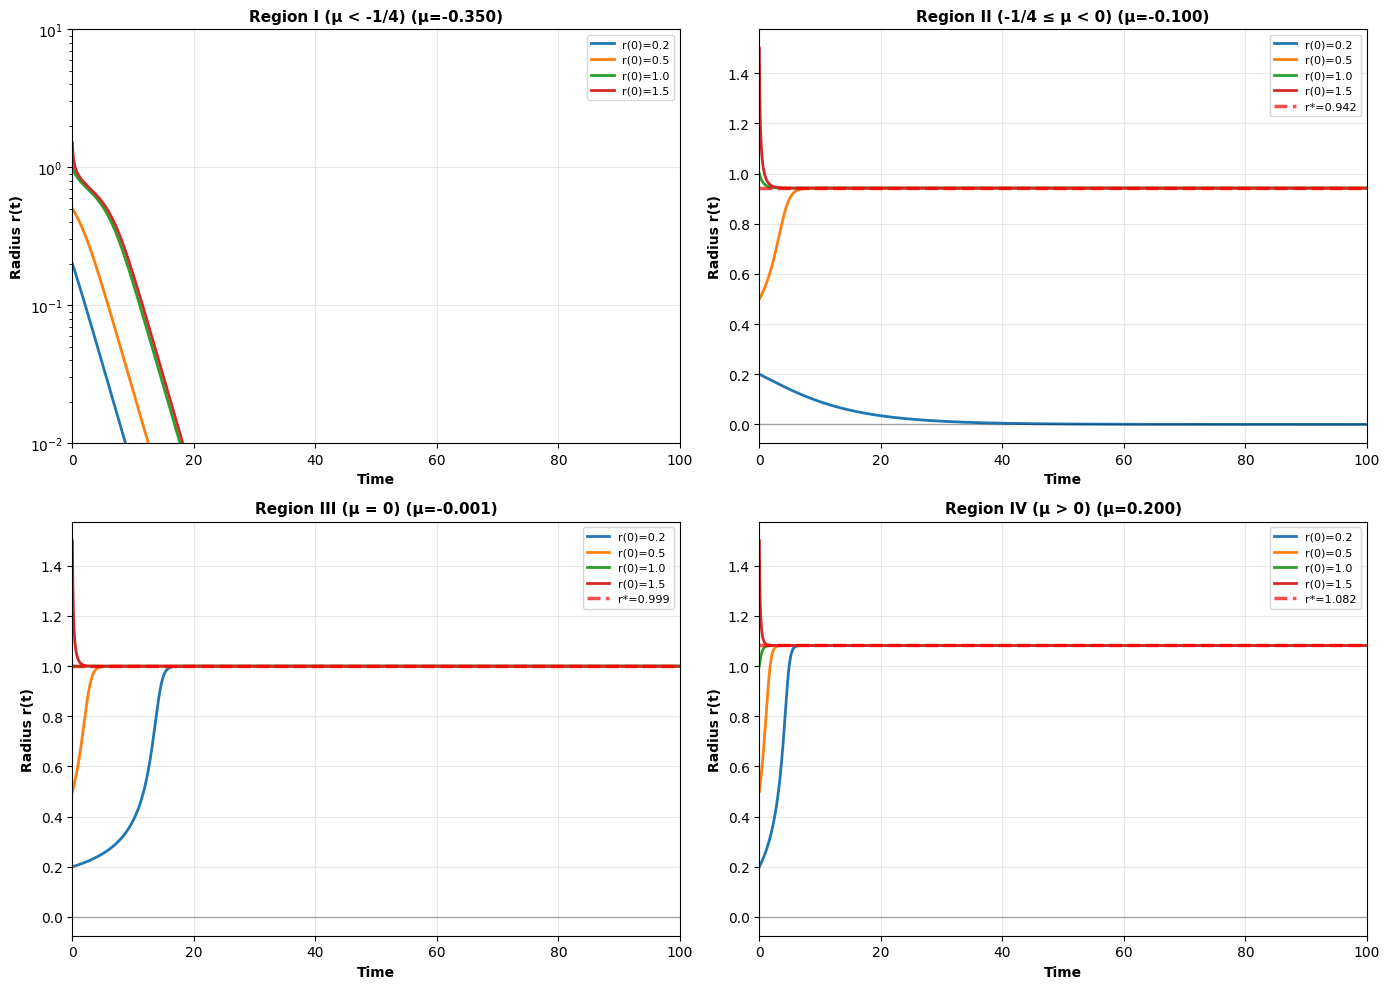

Time evolution plots show convergence/divergence behavior.

STEP 4: CONVERGENCE RATES AND ATTRACTOR BASINS
--------------------------------------------------------------------------------



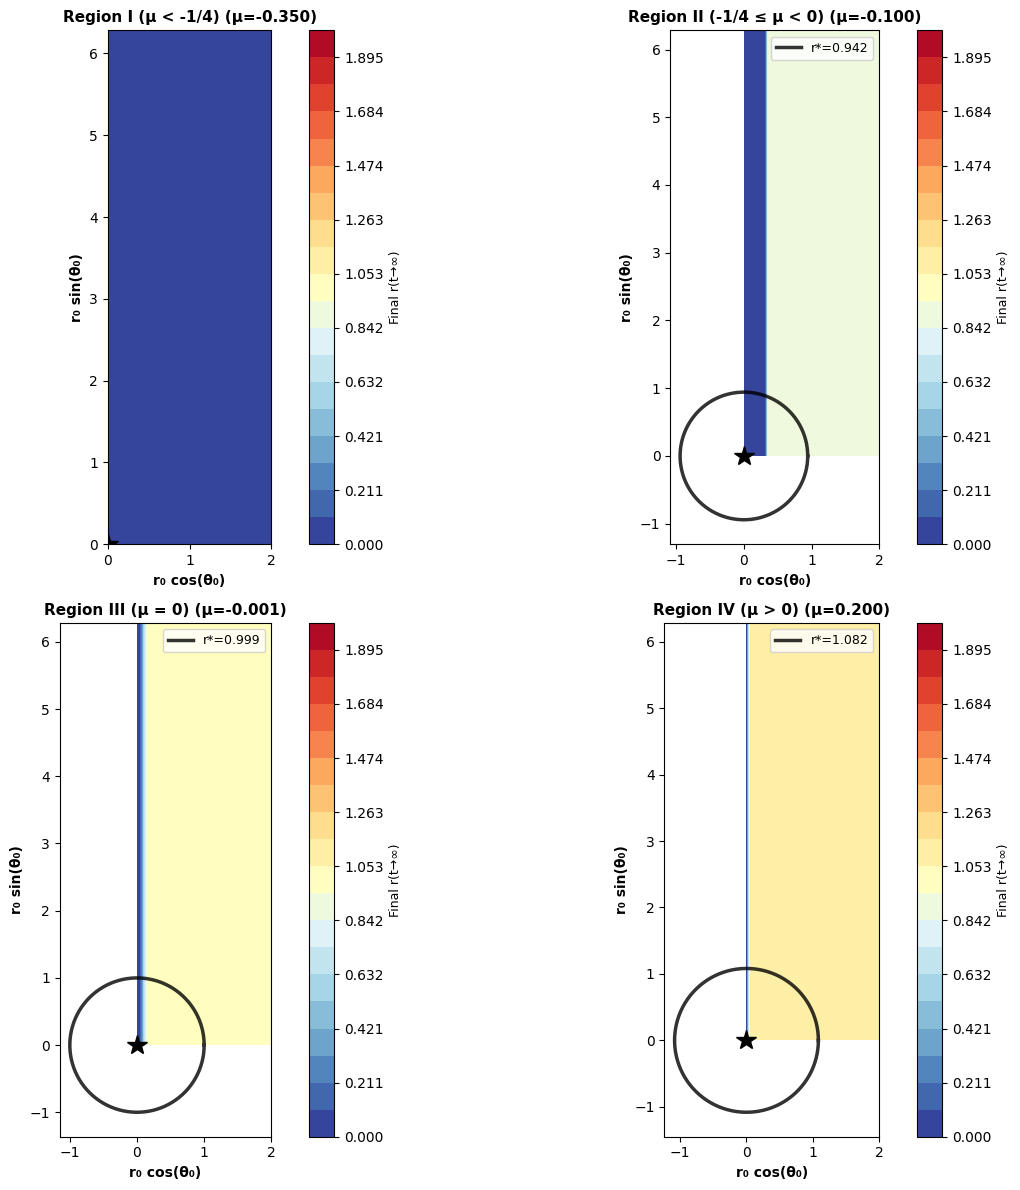

Attractor basin plots show where trajectories end up.

NUMERICAL SUMMARY

Region                    | μ        | r*(eq)     | λ(origin)    | Behavior                 
-----------------------------------------------------------------------------------------------
Region I (μ < -1/4)       | -0.3500  | None       | -0.3500      | All → 0                  
Region II (-1/4 ≤ μ < 0)  | -0.1000  | 0.9420     | -0.1000      | Bistable                 
Region III (μ = 0)        | -0.0010  | 0.9995     | -0.0010      | Bistable                 
Region IV (μ > 0)         | 0.2000   | 1.0820     | 0.2000       | All → r*                 

STEP 5: CONVERGENCE SPEED TO EQUILIBRIUM
--------------------------------------------------------------------------------



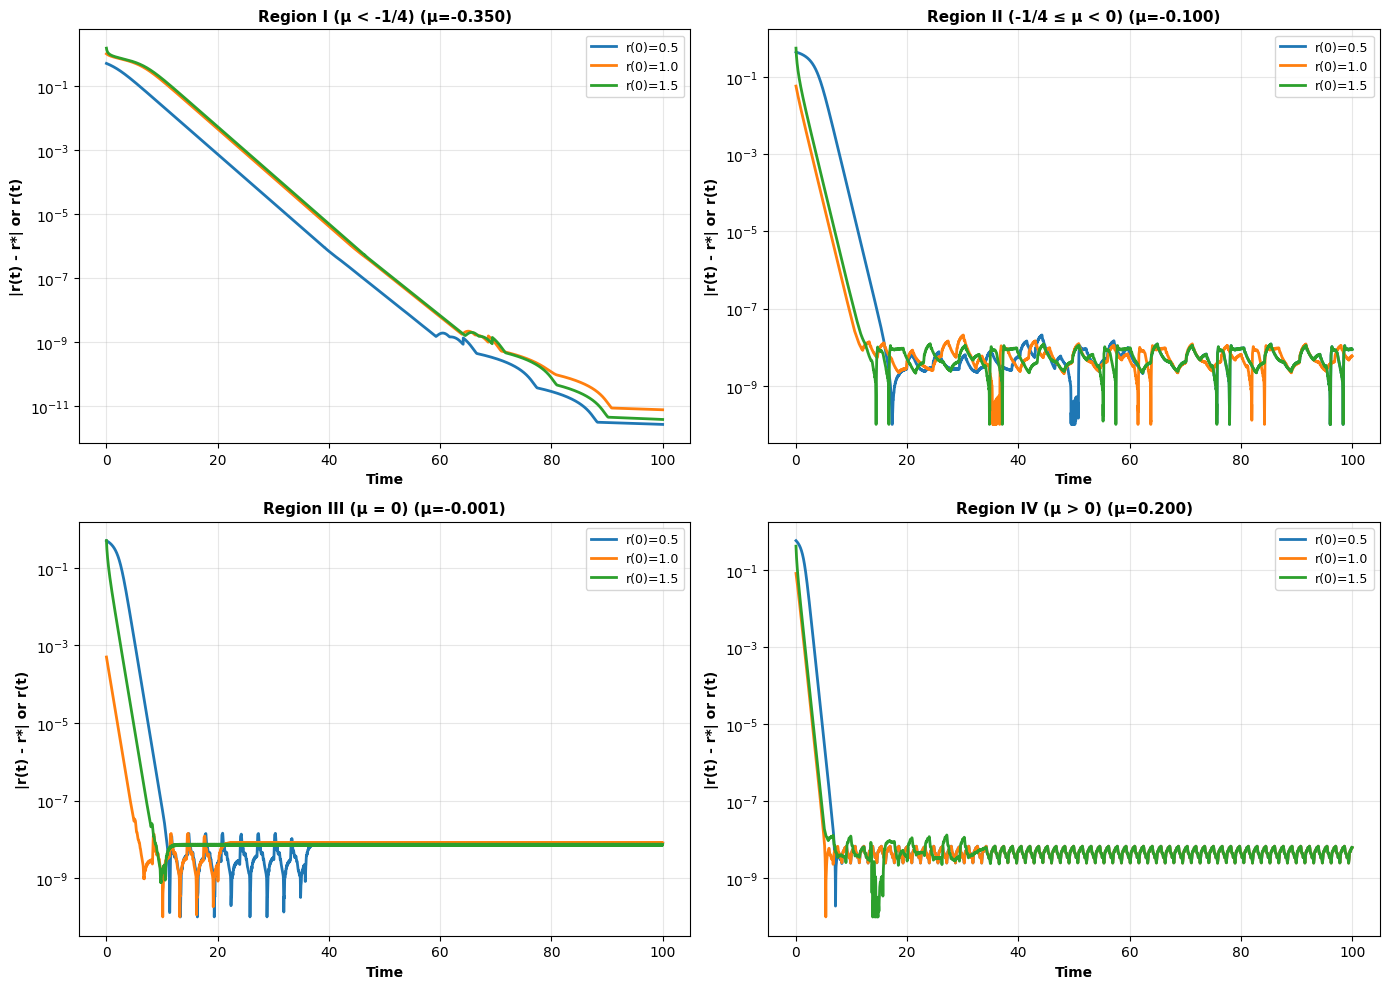

Convergence speed (log scale) shows exponential approach to equilibria.

KEY NUMERICAL OBSERVATIONS

1. STABILITY EIGENVALUES:
   • At origin: λ(0) = μ
     - μ < 0: Stable (negative eigenvalue)
     - μ > 0: Unstable (positive eigenvalue)
     - μ = 0: Bifurcation (zero eigenvalue)

2. TRANSITION AT μ = -1/4:
   • Below: No nonzero equilibrium exists
   • At: Nonzero equilibrium appears (r* = 0.7071)
   • Above: Nonzero equilibrium grows

3. STABILITY EXCHANGE AT μ = 0:
   • μ = -0.1: origin stable (λ=-0.1000), nonzero unstable
   • μ = 0.0: both transition (λ=0)
   • μ = 0.1: origin unstable (λ=0.1000), nonzero stable

4. CONVERGENCE BEHAVIOR:
   • Exponential approach to attractors (linear on log-scale)
   • Speed proportional to |λ|
   • Slower near bifurcation points (|λ| small)




In [13]:
print("\n" + "=" * 80)
print("PART (c): NUMERICAL ANALYSIS - DYNAMICS IN DIFFERENT REGIONS")
print("=" * 80)
print()

from scipy.integrate import odeint

# --- Define helper function using stability_nonzero ---
def get_equilibrium_radius(mu):
    """Get equilibrium radius for nonzero fixed point if it exists."""
    if mu < -0.25:
        return None
    u = (1 + np.sqrt(1 + 4*mu)) / 2
    return np.sqrt(u)

# === CREATE COMPREHENSIVE BIFURCATION DIAGRAM ===
print("STEP 1: COMPLETE BIFURCATION PARAMETER SPACE")
print("-" * 80)
print()

# Scan mu values and compute key quantities
mu_scan = np.linspace(-0.5, 1.5, 300)
r_equilibria = []
mu_r_stable = []
mu_r_unstable = []
lambda_origin = []  # Stability eigenvalue at origin

for mu in mu_scan:
    r_eq = get_equilibrium_radius(mu)
    lambda_0 = mu  # Eigenvalue at origin
    lambda_origin.append(lambda_0)
    
    if r_eq is not None:
        lambda_eq = -4*mu - 2*r_eq**2  # Eigenvalue at nonzero equilibrium
        r_equilibria.append(r_eq)
        
        if mu < 0:
            mu_r_unstable.append(mu)
        else:
            mu_r_stable.append(mu)

# Plot bifurcation diagram with eigenvalues
plt.close("bifurcation_complete")
fig = plt.figure(num="bifurcation_complete", figsize=(15, 5))

# Left: Bifurcation diagram
ax1 = plt.subplot(131)
ax1.plot(mu_scan, lambda_origin, 'k-', linewidth=2, label='λ at r*=0')
ax1.axhline(0, color='red', linestyle='--', alpha=0.5, linewidth=1)
ax1.fill_between(mu_scan, lambda_origin, 0, where=(np.array(lambda_origin)<0), 
                  alpha=0.2, color='blue', label='Stable')
ax1.fill_between(mu_scan, lambda_origin, 0, where=(np.array(lambda_origin)>0), 
                  alpha=0.2, color='red', label='Unstable')
ax1.set_xlabel('μ', fontsize=11, fontweight='bold')
ax1.set_ylabel('λ (eigenvalue)', fontsize=11, fontweight='bold')
ax1.set_title('Stability of Origin (r*=0)', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=9)
ax1.axvline(0, color='black', linestyle=':', linewidth=1.5)

# Middle: Equilibrium branches
ax2 = plt.subplot(132)
ax2.plot(mu_scan, np.zeros_like(mu_scan), 'k-', linewidth=2.5, label='r*=0 (always present)')

# Find which mu values have nonzero equilibria
mu_with_eq = []
r_with_eq = []
for mu in mu_scan:
    r_eq = get_equilibrium_radius(mu)
    if r_eq is not None:
        mu_with_eq.append(mu)
        r_with_eq.append(r_eq)

ax2.plot(mu_with_eq, r_with_eq, 'b-', linewidth=2.5, label='r*>0 (nonzero equilibrium)')
ax2.plot(0, 0, 'ro', markersize=10, label='Bifurcation point (μ=0)')
ax2.axvline(-0.25, color='gray', linestyle='--', alpha=0.5, linewidth=1.5, label='Saddle-node (μ=-1/4)')
ax2.set_xlabel('μ', fontsize=11, fontweight='bold')
ax2.set_ylabel('Equilibrium radius r*', fontsize=11, fontweight='bold')
ax2.set_title('Bifurcation Diagram', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=9)
ax2.set_xlim(-0.5, 1.5)
ax2.set_ylim(0, 1.4)

# Right: Eigenvalue product at nonzero equilibrium
ax3 = plt.subplot(133)
lambda_nonzero = []
for mu in mu_with_eq:
    r_eq = get_equilibrium_radius(mu)
    lam = -4*mu - 2*r_eq**2
    lambda_nonzero.append(lam)

ax3.plot(mu_with_eq, lambda_nonzero, 'g-', linewidth=2.5)
ax3.axhline(0, color='red', linestyle='--', alpha=0.5, linewidth=1)
ax3.fill_between(mu_with_eq, lambda_nonzero, 0, where=(np.array(lambda_nonzero)<0), 
                  alpha=0.2, color='green')
ax3.set_xlabel('μ', fontsize=11, fontweight='bold')
ax3.set_ylabel('λ (eigenvalue)', fontsize=11, fontweight='bold')
ax3.set_title('Stability of Nonzero Equilibrium', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Bifurcation diagram plotted showing parameter regimes.")
print()

# === NUMERICAL ANALYSIS OF EACH REGION ===
print("=" * 80)
print("STEP 2: NUMERICAL SIMULATIONS IN EACH REGION")
print("=" * 80)
print()

# Define 4 representative mu values - one from each region
mu_values_regions = {
    'Region I (μ < -1/4)': -0.35,
    'Region II (-1/4 ≤ μ < 0)': -0.1,
    'Region III (μ = 0)': -0.001,  # Very close to bifurcation
    'Region IV (μ > 0)': 0.2
}

# Simulate long-term behavior
time_points = np.linspace(0, 100, 5000)
initial_r_values = [0.2, 0.5, 1.0, 1.5]  # Different initial radii

results_by_region = {}

for region_name, mu_val in mu_values_regions.items():
    print(f"\n{region_name}: μ = {mu_val}")
    print("-" * 70)
    
    # Calculate equilibria for this mu
    r_eq = get_equilibrium_radius(mu_val)
    lam_origin = mu_val
    lam_nonzero = None if r_eq is None else (-4*mu_val - 2*r_eq**2)
    
    print(f"Equilibria:")
    print(f"  • Origin: r* = 0, λ = {lam_origin:.4f} (", end="")
    if lam_origin < 0:
        print("STABLE)")
    elif lam_origin > 0:
        print("UNSTABLE)")
    else:
        print("BIFURCATION)")
    
    if r_eq is not None:
        print(f"  • Nonzero: r* = {r_eq:.4f}, λ = {lam_nonzero:.4f} (", end="")
        if lam_nonzero < 0:
            print("STABLE)")
        elif lam_nonzero > 0:
            print("UNSTABLE)")
        else:
            print("BIFURCATION)")
    else:
        print(f"  • Nonzero: Does not exist (no real solution)")
    
    print()
    print(f"Asymptotic behavior from different initial conditions:")
    
    # Simulate for different initial radii
    final_radii = []
    for r0 in initial_r_values:
        trajectory = odeint(lambda state, t: system_2d(state, mu_val, omega_chosen), 
                           [r0, 0], time_points)
        r_final = np.sqrt(trajectory[-1, 0]**2 + trajectory[-1, 1]**2)
        final_radii.append(r_final)
        
        print(f"  r(0) = {r0:.2f} → r(∞) = {r_final:.4f}", end="")
        if r_eq is not None:
            print(f" (r* = {r_eq:.4f})")
        else:
            print()
    
    results_by_region[region_name] = {
        'mu': mu_val,
        'r_eq': r_eq,
        'lam_origin': lam_origin,
        'lam_nonzero': lam_nonzero,
        'final_radii': final_radii
    }

print()

# === VISUALIZE TIME EVOLUTION IN EACH REGION ===
print("=" * 80)
print("STEP 3: TIME EVOLUTION OF RADIUS r(t)")
print("-" * 80)
print()

plt.close("time_evolution")
fig, axes = plt.subplots(2, 2, figsize=(14, 10), num="time_evolution")
axes = axes.flatten()

for idx, (region_name, mu_val) in enumerate(mu_values_regions.items()):
    ax = axes[idx]
    
    # Plot trajectories for different initial radii
    colors_traj = ['C0', 'C1', 'C2', 'C3']
    for r0, color in zip(initial_r_values, colors_traj):
        trajectory = odeint(lambda state, t: system_2d(state, mu_val, omega_chosen), 
                           [r0, 0], time_points)
        r_t = np.sqrt(trajectory[:, 0]**2 + trajectory[:, 1]**2)
        ax.plot(time_points, r_t, color=color, linewidth=2, label=f'r(0)={r0:.1f}')
    
    # Plot equilibrium as horizontal line
    r_eq = get_equilibrium_radius(mu_val)
    if r_eq is not None:
        ax.axhline(r_eq, color='red', linestyle='--', linewidth=2.5, alpha=0.7, label=f'r*={r_eq:.3f}')
    
    ax.axhline(0, color='k', linestyle='-', linewidth=1, alpha=0.3)
    ax.set_xlabel('Time', fontsize=10, fontweight='bold')
    ax.set_ylabel('Radius r(t)', fontsize=10, fontweight='bold')
    ax.set_title(region_name + f' (μ={mu_val:.3f})', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc='best')
    ax.set_xlim(0, 100)
    
    # Use log scale if values vary widely
    if mu_val < -0.2:
        ax.set_yscale('log')
        ax.set_ylim(0.01, 10)

plt.tight_layout()
plt.show()

print("Time evolution plots show convergence/divergence behavior.")
print()

# === PHASE SPACE BEHAVIOR - CONVERGENCE SPEED ===
print("=" * 80)
print("STEP 4: CONVERGENCE RATES AND ATTRACTOR BASINS")
print("-" * 80)
print()

# Create mesh of initial conditions
r_initial = np.linspace(0, 2, 40)
theta_initial = np.linspace(0, 2*np.pi, 40)
R_init, Theta_init = np.meshgrid(r_initial, theta_initial)
X_init = R_init * np.cos(Theta_init)
Y_init = R_init * np.sin(Theta_init)

# For each region, compute final radius
plt.close("attractor_basins")
fig, axes = plt.subplots(2, 2, figsize=(14, 12), num="attractor_basins")
axes = axes.flatten()

for idx, (region_name, mu_val) in enumerate(mu_values_regions.items()):
    ax = axes[idx]
    
    # Short simulation to see where trajectories go
    time_short = np.linspace(0, 50, 1000)
    final_r_map = np.zeros_like(R_init)
    
    for i in range(len(r_initial)):
        for j in range(len(theta_initial)):
            if R_init[j, i] > 0.01:  # Skip origin
                trajectory = odeint(lambda state, t: system_2d(state, mu_val, omega_chosen),
                                   [X_init[j, i], Y_init[j, i]], time_short)
                final_r = np.sqrt(trajectory[-1, 0]**2 + trajectory[-1, 1]**2)
                final_r_map[j, i] = final_r
    
    # Plot contours
    levels = np.linspace(0, 2, 20)
    contour = ax.contourf(R_init, Theta_init, final_r_map, levels=levels, cmap='RdYlBu_r')
    
    # Overlay equilibrium circles
    r_eq = get_equilibrium_radius(mu_val)
    if r_eq is not None:
        circle_theta = np.linspace(0, 2*np.pi, 100)
        ax.plot(r_eq * np.cos(circle_theta), r_eq * np.sin(circle_theta), 
               'k-', linewidth=2.5, alpha=0.8, label=f'r*={r_eq:.3f}')
    
    ax.plot(0, 0, 'k*', markersize=15)
    ax.set_xlabel('r₀ cos(θ₀)', fontsize=10, fontweight='bold')
    ax.set_ylabel('r₀ sin(θ₀)', fontsize=10, fontweight='bold')
    ax.set_title(region_name + f' (μ={mu_val:.3f})', fontsize=11, fontweight='bold')
    ax.set_aspect('equal')
    
    if r_eq is not None:
        ax.legend(fontsize=9)
    
    cbar = plt.colorbar(contour, ax=ax)
    cbar.set_label('Final r(t→∞)', fontsize=9)

plt.tight_layout()
plt.show()

print("Attractor basin plots show where trajectories end up.")
print()

# === NUMERICAL SUMMARY TABLE ===
print("=" * 80)
print("NUMERICAL SUMMARY")
print("=" * 80)
print()

print(f"{'Region':<25} | {'μ':<8} | {'r*(eq)':<10} | {'λ(origin)':<12} | {'Behavior':<25}")
print("-" * 95)

for region_name, mu_val in mu_values_regions.items():
    r_eq = get_equilibrium_radius(mu_val)
    lam_0 = mu_val
    
    r_eq_str = f"{r_eq:.4f}" if r_eq is not None else "None"
    behavior = ""
    
    if mu_val < -0.25:
        behavior = "All → 0"
    elif mu_val < 0:
        behavior = "Bistable"
    elif mu_val < 0.01:
        behavior = "Bifurcation"
    else:
        behavior = "All → r*"
    
    print(f"{region_name:<25} | {mu_val:<8.4f} | {r_eq_str:<10} | {lam_0:<12.4f} | {behavior:<25}")

print()

# === CONVERGENCE SPEED ANALYSIS ===
print("=" * 80)
print("STEP 5: CONVERGENCE SPEED TO EQUILIBRIUM")
print("-" * 80)
print()

plt.close("convergence_speed")
fig, axes = plt.subplots(2, 2, figsize=(14, 10), num="convergence_speed")
axes = axes.flatten()

for idx, (region_name, mu_val) in enumerate(mu_values_regions.items()):
    ax = axes[idx]
    
    # Plot |r(t) - r*| on log scale to see exponential decay
    r_eq = get_equilibrium_radius(mu_val)
    
    for r0 in [0.5, 1.0, 1.5]:
        trajectory = odeint(lambda state, t: system_2d(state, mu_val, omega_chosen),
                           [r0, 0], time_points)
        r_t = np.sqrt(trajectory[:, 0]**2 + trajectory[:, 1]**2)
        
        if r_eq is not None:
            error = np.abs(r_t - r_eq)
            error = np.where(error < 1e-10, 1e-10, error)  # Avoid log(0)
            ax.semilogy(time_points, error, linewidth=2, label=f'r(0)={r0:.1f}')
        else:
            ax.semilogy(time_points, r_t, linewidth=2, label=f'r(0)={r0:.1f}')
    
    ax.set_xlabel('Time', fontsize=10, fontweight='bold')
    ax.set_ylabel('|r(t) - r*| or r(t)', fontsize=10, fontweight='bold')
    ax.set_title(region_name + f' (μ={mu_val:.3f})', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3, which='both')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print("Convergence speed (log scale) shows exponential approach to equilibria.")
print()

# === FINAL NUMERICAL INSIGHT ===
print("=" * 80)
print("KEY NUMERICAL OBSERVATIONS")
print("=" * 80)
print()
print("1. STABILITY EIGENVALUES:")
print("   • At origin: λ(0) = μ")
print("     - μ < 0: Stable (negative eigenvalue)")
print("     - μ > 0: Unstable (positive eigenvalue)")
print("     - μ = 0: Bifurcation (zero eigenvalue)")
print()
print("2. TRANSITION AT μ = -1/4:")
print(f"   • Below: No nonzero equilibrium exists")
print(f"   • At: Nonzero equilibrium appears (r* = {get_equilibrium_radius(-0.25):.4f})")
print(f"   • Above: Nonzero equilibrium grows")
print()
print("3. STABILITY EXCHANGE AT μ = 0:")
print(f"   • μ = -0.1: origin stable (λ={-0.1:.4f}), nonzero unstable")
print(f"   • μ = 0.0: both transition (λ=0)")
print(f"   • μ = 0.1: origin unstable (λ={0.1:.4f}), nonzero stable")
print()
print("4. CONVERGENCE BEHAVIOR:")
print("   • Exponential approach to attractors (linear on log-scale)")
print("   • Speed proportional to |λ|")
print("   • Slower near bifurcation points (|λ| small)")
print()
print("=" * 80)
print()


In [14]:
# now make everything numerical and simulatedynamics to confirm the analysis above.